# ⚖️ Métriques de Fairness Complètes

Objectif : documenter exhaustivement toutes les violations de fairness avec intervalles de confiance, courbes ROC et optimisation de seuils.

In [1]:
# Cellule 1: Setup
import os, json, pickle, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Répertoire de travail = experiments/
if os.path.basename(os.getcwd()) != 'experiments':
    if (Path(os.getcwd()) / 'experiments').exists():
        os.chdir(Path(os.getcwd()) / 'experiments')
# Ajouter utils/ au path Python
sys.path.insert(0, str(Path(os.getcwd()).parent / 'utils'))
print(f'📁 Répertoire: {os.getcwd()}')

RESULTS = Path('../results/phase3')
FIGS    = RESULTS / 'figures'
RESULTS.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)
from sklearn.metrics import roc_auc_score
from fairness_metrics import (
    compute_fairness_metrics, compute_predictive_parity,
    bootstrap_ci, roc_by_group, find_fair_thresholds
)
print('✅ Imports OK')


📁 Répertoire: /Users/antoinedalle/Desktop/Period_3/Fair_AI/Projet/NLP_fairness_project/experiments
✅ Imports OK


In [2]:
# Cellule 2: Données + embeddings
with open('models/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

def load_jsonl(p):
    data = []
    with open(p, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip(): data.append(json.loads(line))
    return data

df_train = pd.DataFrame(load_jsonl('medical_bios_data/train.jsonl'))
df_test  = pd.DataFrame(load_jsonl('medical_bios_data/test.jsonl'))
y_train  = le.transform(df_train['title'])
y_test   = le.transform(df_test['title'])
genders  = df_test['gender'].values

# Charger embeddings du meilleur modèle
try:
    with open('../results/phase2/best_embedding_model.json') as f:
        best_info = json.load(f)
    model_id = best_info['model_id']
    print(f'📦 Embeddings: {best_info["label"]}')
except FileNotFoundError:
    model_id = 'distilroberta-base'
    print(f'⚠️  Utilisation de {model_id} par défaut')

safe = model_id.replace('/', '_')
CACHE = Path('embedding_cache')
emb_train = np.load(list(CACHE.glob(f'{safe}_{len(df_train)}*.npy'))[0])
emb_test  = np.load(list(CACHE.glob(f'{safe}_{len(df_test)}*.npy'))[0])
print(f'✅ Embeddings — train: {emb_train.shape}, test: {emb_test.shape}')


📦 Embeddings: DistilRoBERTa
✅ Embeddings — train: (8000, 768), test: (1000, 768)


In [3]:
# Cellule 3: Charger RF
# Charger ou entraîner le meilleur RF sur embeddings
RF_PATH = Path('models/best_rf_embeddings.pkl')

if RF_PATH.exists():
    with open(RF_PATH, 'rb') as f:
        rf = pickle.load(f)
    print('📦 RF chargé depuis cache')
else:
    from sklearn.ensemble import RandomForestClassifier
    try:
        with open('../results/phase2/best_rf_params.json') as f:
            p = json.load(f)
    except FileNotFoundError:
        p = {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 2}
    rf = RandomForestClassifier(
        n_estimators=p['n_estimators'],
        max_depth=p['max_depth'],
        min_samples_split=p['min_samples_split'],
        random_state=42, n_jobs=-1
    )
    print('🔄 Entraînement RF...')
    rf.fit(emb_train, y_train)
    with open(RF_PATH, 'wb') as f:
        pickle.dump(rf, f)
    print(f'✅ RF entraîné et sauvegardé → {RF_PATH}')

y_pred  = rf.predict(emb_test)
y_proba = rf.predict_proba(emb_test)
print(f'🎯 Accuracy: {(y_pred == y_test).mean():.4f}')


📦 RF chargé depuis cache
🎯 Accuracy: 0.8990


## 1️⃣ Métriques de Base + Intervalles de Confiance (Bootstrap)

In [4]:
# Cellule 4: Toutes les métriques avec bootstrap CI
METRICS = ['accuracy', 'delta_dp', 'delta_eo', 'delta_eqodds']
N_BOOTSTRAP = 2000

print(f'🔄 Bootstrap CI ({N_BOOTSTRAP} itérations)...')

ci_rows = []
for metric in METRICS:
    mean_val, lo, hi = bootstrap_ci(y_test, y_pred, genders, le.classes_,
                                     metric=metric, n_iter=N_BOOTSTRAP)
    flag = ''
    if metric != 'accuracy' and lo > 0.05: flag = '🚨 ROBUSTE'
    elif metric != 'accuracy' and lo > 0.01: flag = '⚠️'
    ci_rows.append({'metric': metric, 'value': mean_val, 'ci_low': lo, 'ci_high': hi, 'note': flag})
    print(f'  {metric:20s}: {mean_val:.4f}  CI=[{lo:.4f}, {hi:.4f}]  {flag}')

ci_df = pd.DataFrame(ci_rows)

# Predictive Parity
pp = compute_predictive_parity(y_test, y_pred, genders, le.classes_)
print('\n🔍 PREDICTIVE PARITY (∆PPV par profession):')
for prof, v in pp.items():
    flag = '🚨' if v['gap'] > 0.1 else '✅'
    print(f'  {flag} {prof}: PPV_female={v.get("ppv_female",float("nan")):.3f}  '
          f'PPV_male={v.get("ppv_male",float("nan")):.3f}  gap={v["gap"]:.3f}')


🔄 Bootstrap CI (2000 itérations)...
  accuracy            : 0.8986  CI=[0.8800, 0.9160]  
  delta_dp            : 0.1748  CI=[0.1536, 0.1959]  🚨 ROBUSTE
  delta_eo            : 0.1810  CI=[0.1122, 0.2505]  🚨 ROBUSTE
  delta_eqodds        : 0.1832  CI=[0.1154, 0.2533]  🚨 ROBUSTE

🔍 PREDICTIVE PARITY (∆PPV par profession):
  ✅ dentist: PPV_female=0.968  PPV_male=0.992  gap=0.024
  ✅ nurse: PPV_female=0.886  PPV_male=0.900  gap=0.014
  ✅ physician: PPV_female=0.843  PPV_male=0.850  gap=0.007
  ✅ psychologist: PPV_female=0.904  PPV_male=0.864  gap=0.040
  ✅ surgeon: PPV_female=0.923  PPV_male=0.879  gap=0.044


## 2️⃣ Courbes ROC par Genre

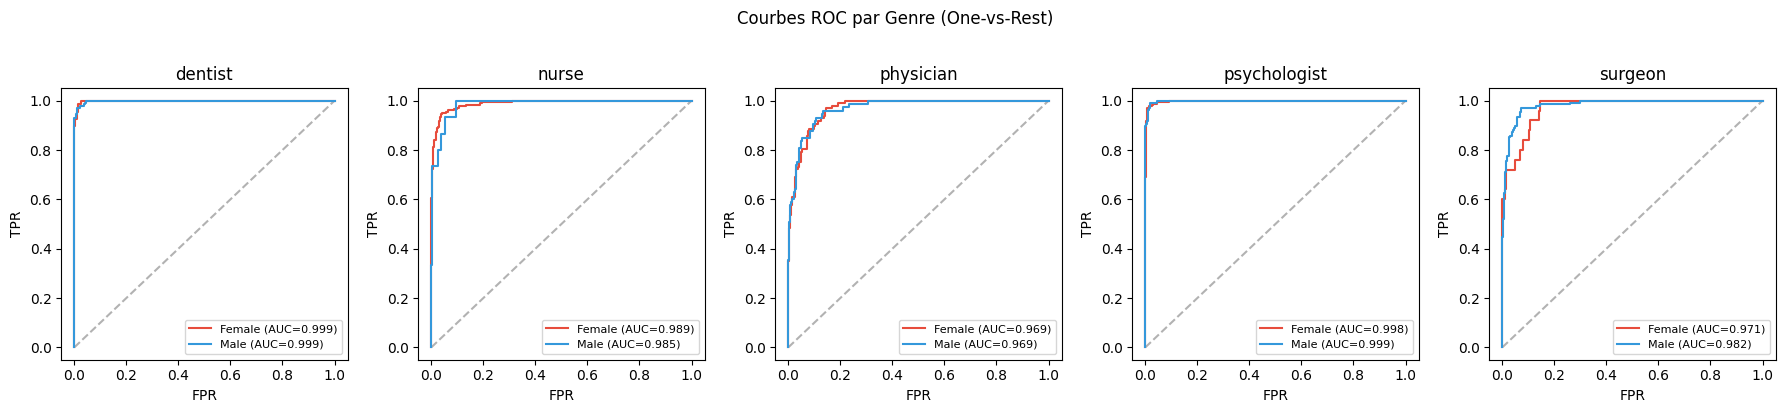


📊 AUC par Genre et Profession:
gender        Female   Male
profession                 
dentist        0.999  0.999
nurse          0.989  0.985
physician      0.969  0.969
psychologist   0.998  0.999
surgeon        0.971  0.982


In [5]:
# Cellule 5: Courbes ROC OvR par genre
roc_results = roc_by_group(y_test, y_proba, genders, le.classes_)

fig, axes = plt.subplots(1, len(le.classes_), figsize=(18, 4))

auc_rows = []
for cid, (cls, ax) in enumerate(zip(le.classes_, axes)):
    ax.plot([0,1],[0,1],'k--', alpha=0.3)
    for g, color in [('Female','#e74c3c'), ('Male','#3498db')]:
        if g in roc_results.get(cls, {}):
            d = roc_results[cls][g]
            ax.plot(d['fpr'], d['tpr'], color=color,
                    label=f'{g} (AUC={d["auc"]:.3f})')
            auc_rows.append({'profession': cls, 'gender': g, 'auc': d['auc']})
    ax.set_title(cls)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=8)

plt.suptitle('Courbes ROC par Genre (One-vs-Rest)', y=1.02)
plt.tight_layout()
plt.savefig(FIGS / 'roc_curves_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()

auc_df = pd.DataFrame(auc_rows)
print('\n📊 AUC par Genre et Profession:')
print(auc_df.pivot(index='profession', columns='gender', values='auc').round(3).to_string())


## 3️⃣ Impact des Seuils de Décision

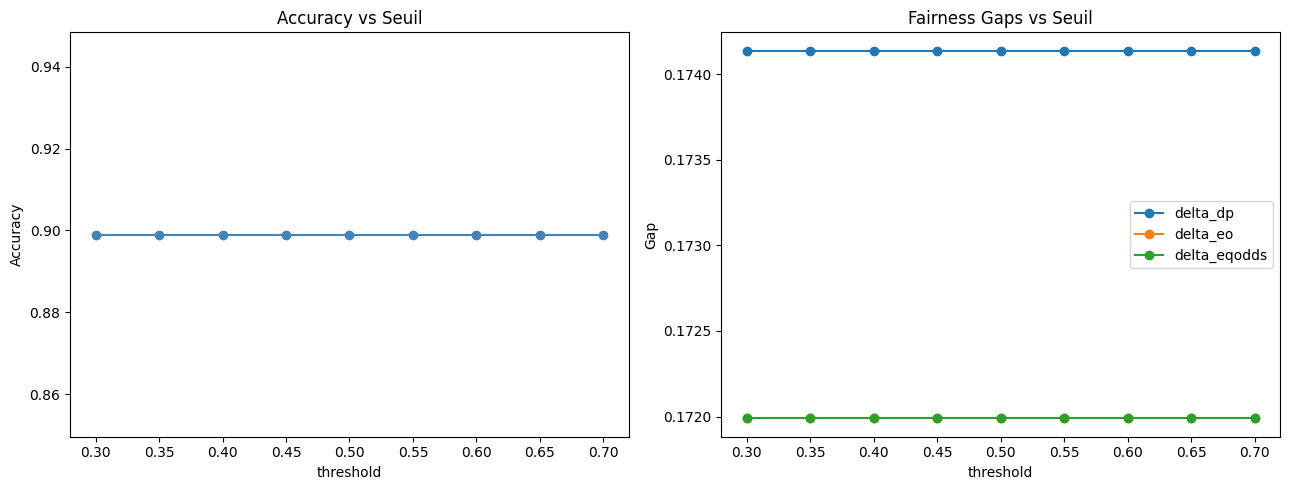

In [6]:
# Cellule 6: Métriques à différents seuils globaux (0.3 à 0.7)
thresholds_range = np.arange(0.3, 0.75, 0.05)
thresh_rows = []

for t in thresholds_range:
    # Appliquer seuil : si max_proba < t → classe la plus probable quand même
    y_pred_t = np.where(y_proba.max(axis=1) >= t, y_proba.argmax(axis=1), y_pred)
    fm = compute_fairness_metrics(y_test, y_pred_t, genders, le.classes_)
    fm['threshold'] = round(t, 2)
    thresh_rows.append(fm)

thresh_df = pd.DataFrame(thresh_rows).set_index('threshold')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
thresh_df['accuracy'].plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Accuracy vs Seuil')
axes[0].set_ylabel('Accuracy')

thresh_df[['delta_dp','delta_eo','delta_eqodds']].plot(ax=axes[1], marker='o')
axes[1].set_title('Fairness Gaps vs Seuil')
axes[1].set_ylabel('Gap')

plt.tight_layout()
plt.savefig(FIGS / 'threshold_impact.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
# Cellule 7: Seuils différenciés par genre (post-processing fairness)
print('🎛️  OPTIMISATION DES SEUILS PAR GENRE')
print('='*50)

for criterion, label in [('dp', 'Demographic Parity'), ('eo', 'Equality of Opportunity')]:
    fair_thresh = find_fair_thresholds(y_test, y_proba, genders, le.classes_, criterion=criterion)

    # Appliquer les seuils différenciés
    y_pred_fair = y_pred.copy()
    for cid, cls in enumerate(le.classes_):
        for g in np.unique(genders):
            m = genders == g
            t = fair_thresh[cls].get(g, 0.5)
            # Réassigner si la proba de la classe dépasse le seuil du groupe
            reassign = m & (y_proba[:, cid] >= t)
            y_pred_fair[reassign] = cid

    fm_fair = compute_fairness_metrics(y_test, y_pred_fair, genders, le.classes_)
    fm_base = compute_fairness_metrics(y_test, y_pred,      genders, le.classes_)

    print(f'\n{label}:')
    for k in ['accuracy','delta_dp','delta_eo','delta_eqodds']:
        delta = fm_fair[k] - fm_base[k]
        arrow = '↑' if delta > 0 else '↓'
        print(f'  {k:20s}: {fm_base[k]:.4f} → {fm_fair[k]:.4f}  ({arrow}{abs(delta):.4f})')


🎛️  OPTIMISATION DES SEUILS PAR GENRE

Demographic Parity:
  accuracy            : 0.8990 → 0.8600  (↓0.0390)
  delta_dp            : 0.1741 → 0.1241  (↓0.0500)
  delta_eo            : 0.1720 → 0.0472  (↓0.1248)
  delta_eqodds        : 0.1720 → 0.0505  (↓0.1215)

Equality of Opportunity:
  accuracy            : 0.8990 → 0.5400  (↓0.3590)
  delta_dp            : 0.1741 → 0.0484  (↓0.1258)
  delta_eo            : 0.1720 → 0.1529  (↓0.0191)
  delta_eqodds        : 0.1720 → 0.1878  (↑0.0158)


## 📝 Rapport de Violations

In [8]:
# Cellule 8: Rapport exhaustif des violations
print('📝 RAPPORT EXHAUSTIF DES VIOLATIONS DE FAIRNESS')
print('='*55)

THRESHOLD_VIOLATION = 0.05  # seuil plus strict qu'en phase 1 (10%)

violation_rows = []
for cid, cls in enumerate(le.classes_):
    for g_pair in [('Female','Male')]:
        g0, g1 = g_pair
        m0, m1 = genders == g0, genders == g1

        dp   = abs(np.mean(y_pred[m0]==cid) - np.mean(y_pred[m1]==cid))
        pm0  = m0 & (y_test==cid); pm1 = m1 & (y_test==cid)
        tpr0 = np.mean(y_pred[pm0]==cid) if pm0.sum()>0 else 0
        tpr1 = np.mean(y_pred[pm1]==cid) if pm1.sum()>0 else 0
        eo   = abs(tpr0 - tpr1)
        ppv_info = pp.get(cls, {})
        ppv_gap  = ppv_info.get('gap', 0)

        violations = []
        if dp   > THRESHOLD_VIOLATION: violations.append(f'∆DP={dp:.3f}')
        if eo   > THRESHOLD_VIOLATION: violations.append(f'∆EO={eo:.3f}')
        if ppv_gap > THRESHOLD_VIOLATION: violations.append(f'∆PPV={ppv_gap:.3f}')

        severity = '🚨 HAUTE' if len(violations)>=2 else ('⚠️  MOYENNE' if violations else '✅ OK')
        violation_rows.append({'profession': cls, 'comparison': f'{g0} vs {g1}',
                                'delta_dp': dp, 'delta_eo': eo, 'ppv_gap': ppv_gap,
                                'violations': ', '.join(violations) or 'aucune',
                                'severity': severity})
        print(f'  {severity} | {cls:14s} | {(", ".join(violations)) or "aucune violation"}')

violations_df = pd.DataFrame(violation_rows)
n_high = (violations_df['severity'].str.startswith('🚨')).sum()
n_med  = (violations_df['severity'].str.startswith('⚠️')).sum()
print(f'\n🔢 Haute sévérité : {n_high}/{len(violations_df)}')
print(f'   Sévérité moyenne: {n_med}/{len(violations_df)}')


📝 RAPPORT EXHAUSTIF DES VIOLATIONS DE FAIRNESS
  ⚠️  MOYENNE | dentist        | ∆DP=0.153
  🚨 HAUTE | nurse          | ∆DP=0.336, ∆EO=0.350
  ✅ OK | physician      | aucune violation
  ⚠️  MOYENNE | psychologist   | ∆DP=0.076
  🚨 HAUTE | surgeon        | ∆DP=0.282, ∆EO=0.445

🔢 Haute sévérité : 2/5
   Sévérité moyenne: 2/5


In [9]:
# Cellule 9: Sauvegarder tout
ci_df.to_csv(RESULTS / 'bootstrap_confidence_intervals.csv', index=False)
auc_df.to_csv(RESULTS / 'roc_auc_by_gender.csv', index=False)
thresh_df.to_csv(RESULTS / 'threshold_impact.csv')
violations_df.to_csv(RESULTS / 'fairness_violations_report.csv', index=False)

print('💾 bootstrap_confidence_intervals.csv')
print('💾 roc_auc_by_gender.csv')
print('💾 threshold_impact.csv')
print('💾 fairness_violations_report.csv')
print('\n🎉 Phase 3 terminée!')
print('\n🎯 PROCHAINE ÉTAPE → Phase 4 (Mitigation)')
print(f'  Professions prioritaires : {violations_df[violations_df["severity"].str.startswith("🚨")]["profession"].tolist()}')


💾 bootstrap_confidence_intervals.csv
💾 roc_auc_by_gender.csv
💾 threshold_impact.csv
💾 fairness_violations_report.csv

🎉 Phase 3 terminée!

🎯 PROCHAINE ÉTAPE → Phase 4 (Mitigation)
  Professions prioritaires : [np.str_('nurse'), np.str_('surgeon')]
